# SparseGaze Overall Evaluation Viewer

Dataset-level missing-frame evaluation across ADT sequences. The main comparison uses frames shared by every selected method within each sequence, so the reported method differences are not caused by different frame coverage.

In [1]:
from pathlib import Path
import importlib
import sys

EXPERIMENT_DIR = Path.cwd()
if EXPERIMENT_DIR.name != "sparsegaze_evaluation":
    EXPERIMENT_DIR = Path("/home/liumu/Github_Projects/adt_dataset_sandbox/Experiments/sparsegaze_evaluation")
REPO_ROOT = EXPERIMENT_DIR.parents[1]
sys.path.insert(0, str(EXPERIMENT_DIR))
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import event_evaluation as event_eval
import overall_evaluation as overall

event_eval = importlib.reload(event_eval)
overall = importlib.reload(overall)

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)

print("experiment:", EXPERIMENT_DIR)
print("reports:", event_eval.DEFAULT_REPORTS_DIR)
print("SparseGaze:", event_eval.DEFAULT_SPARSEGAZE_DIR)

experiment: /home/liumu/Github_Projects/adt_dataset_sandbox/Experiments/sparsegaze_evaluation
reports: /mnt/d/SparseGaze/ADT-Gaze-structured
SparseGaze: /home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze_cpf_forward_head_motion_residual_ss


## Configuration

In [2]:
FPS = 6
MODES = list(event_eval.SPARSEGAZE_MODES.keys())
INCLUDE_HAGI = True
USE_COMMON_FRAMES = True

# Set to a short list of sequence names to debug. Keep None for all available sequences.
SEQUENCES = None

print("modes:", MODES)
print("include_hagi:", INCLUDE_HAGI)
print("main_frame_policy:", "common frames" if USE_COMMON_FRAMES else "all available frames")

modes: ['rollout', 'rollout_linear', 'rollout_pchip', 'rollout_gt']
include_hagi: True
main_frame_policy: common frames


## Load Dataset-Level Errors

In [3]:
all_errors = overall.load_dataset_event_errors(
    fps=FPS,
    modes=MODES,
    sequences=SEQUENCES,
    include_hagi=INCLUDE_HAGI,
    common_frames=False,
)
main_errors = overall.keep_common_frames(all_errors) if USE_COMMON_FRAMES else all_errors

coverage = overall.summarize_frame_coverage(all_errors, main_errors)
overall_summary = overall.summarize_overall(main_errors)
sequence_summary = overall.summarize_by_sequence(main_errors)
event_summary = overall.summarize_by_event(main_errors)
event_contrast = overall.summarize_event_contrast(event_summary)
win_counts = overall.summarize_win_counts(sequence_summary)

print("sequences:", main_errors["sequence"].nunique())
print("methods:", list(main_errors["method"].drop_duplicates()))
print("rows:", len(main_errors))

display(coverage.round(4))
display(overall_summary.round(4))

sequences: 10
methods: ['HAGI++', 'SparseGaze gt-repair', 'SparseGaze linear', 'SparseGaze pchip', 'SparseGaze rollout']
rows: 103655


,method,mode,sequence_n,all_available_frame_n,retained_frame_n,retained_ratio
0,HAGI++,hagi++,10,20731,20731,1.0000
1,SparseGaze gt-repair,rollout_gt,10,21803,20731,0.9508
2,SparseGaze linear,rollout_linear,10,21803,20731,0.9508
3,SparseGaze pchip,rollout_pchip,10,21803,20731,0.9508
4,SparseGaze rollout,rollout,10,21803,20731,0.9508


,method,mode,sequence_n,frame_n,frame_weighted_mae_deg,sequence_macro_mae_deg,median_deg,p90_deg
1,SparseGaze gt-repair,rollout_gt,10,20731,2.9300,2.9291,1.0511,8.2950
2,SparseGaze linear,rollout_linear,10,20731,3.0406,3.0396,1.1192,8.6065
3,SparseGaze pchip,rollout_pchip,10,20731,3.0445,3.0435,1.1356,8.5930
0,HAGI++,hagi++,10,20731,3.0958,3.0949,1.2030,8.7497
4,SparseGaze rollout,rollout,10,20731,3.1135,3.1124,1.2994,8.4893


## Event and Sequence Summaries

In [4]:
event_pivot = event_summary.pivot_table(
    index="scene_event_label",
    columns="method",
    values="sequence_macro_mae_deg",
)
event_order = [label for label in overall.EVENT_ORDER if label in event_pivot.index]

display(event_pivot.loc[event_order].round(4))
display(event_contrast.round(4))
display(win_counts.round(4))

method,HAGI++,SparseGaze gt-repair,SparseGaze linear,SparseGaze pchip,SparseGaze rollout
scene_event_label,,,,,
fixation,1.2069,1.0863,1.1505,1.1644,1.3018
transition,4.3810,4.1869,4.3304,4.3273,4.3496


,method,mode,fixation_sequence_macro_mae_deg,transition_sequence_macro_mae_deg,transition_minus_fixation_mae_deg
0,SparseGaze gt-repair,rollout_gt,1.0863,4.1869,3.1006
1,SparseGaze linear,rollout_linear,1.1505,4.3304,3.1799
2,SparseGaze pchip,rollout_pchip,1.1644,4.3273,3.1630
3,HAGI++,hagi++,1.2069,4.3810,3.1741
4,SparseGaze rollout,rollout,1.3018,4.3496,3.0478


,method,win_n,sequence_n,mean_rank
0,SparseGaze gt-repair,10,10,1.0
1,SparseGaze linear,0,10,2.4
2,SparseGaze pchip,0,10,2.8
3,HAGI++,0,10,4.4
4,SparseGaze rollout,0,10,4.4


## Overall Figures

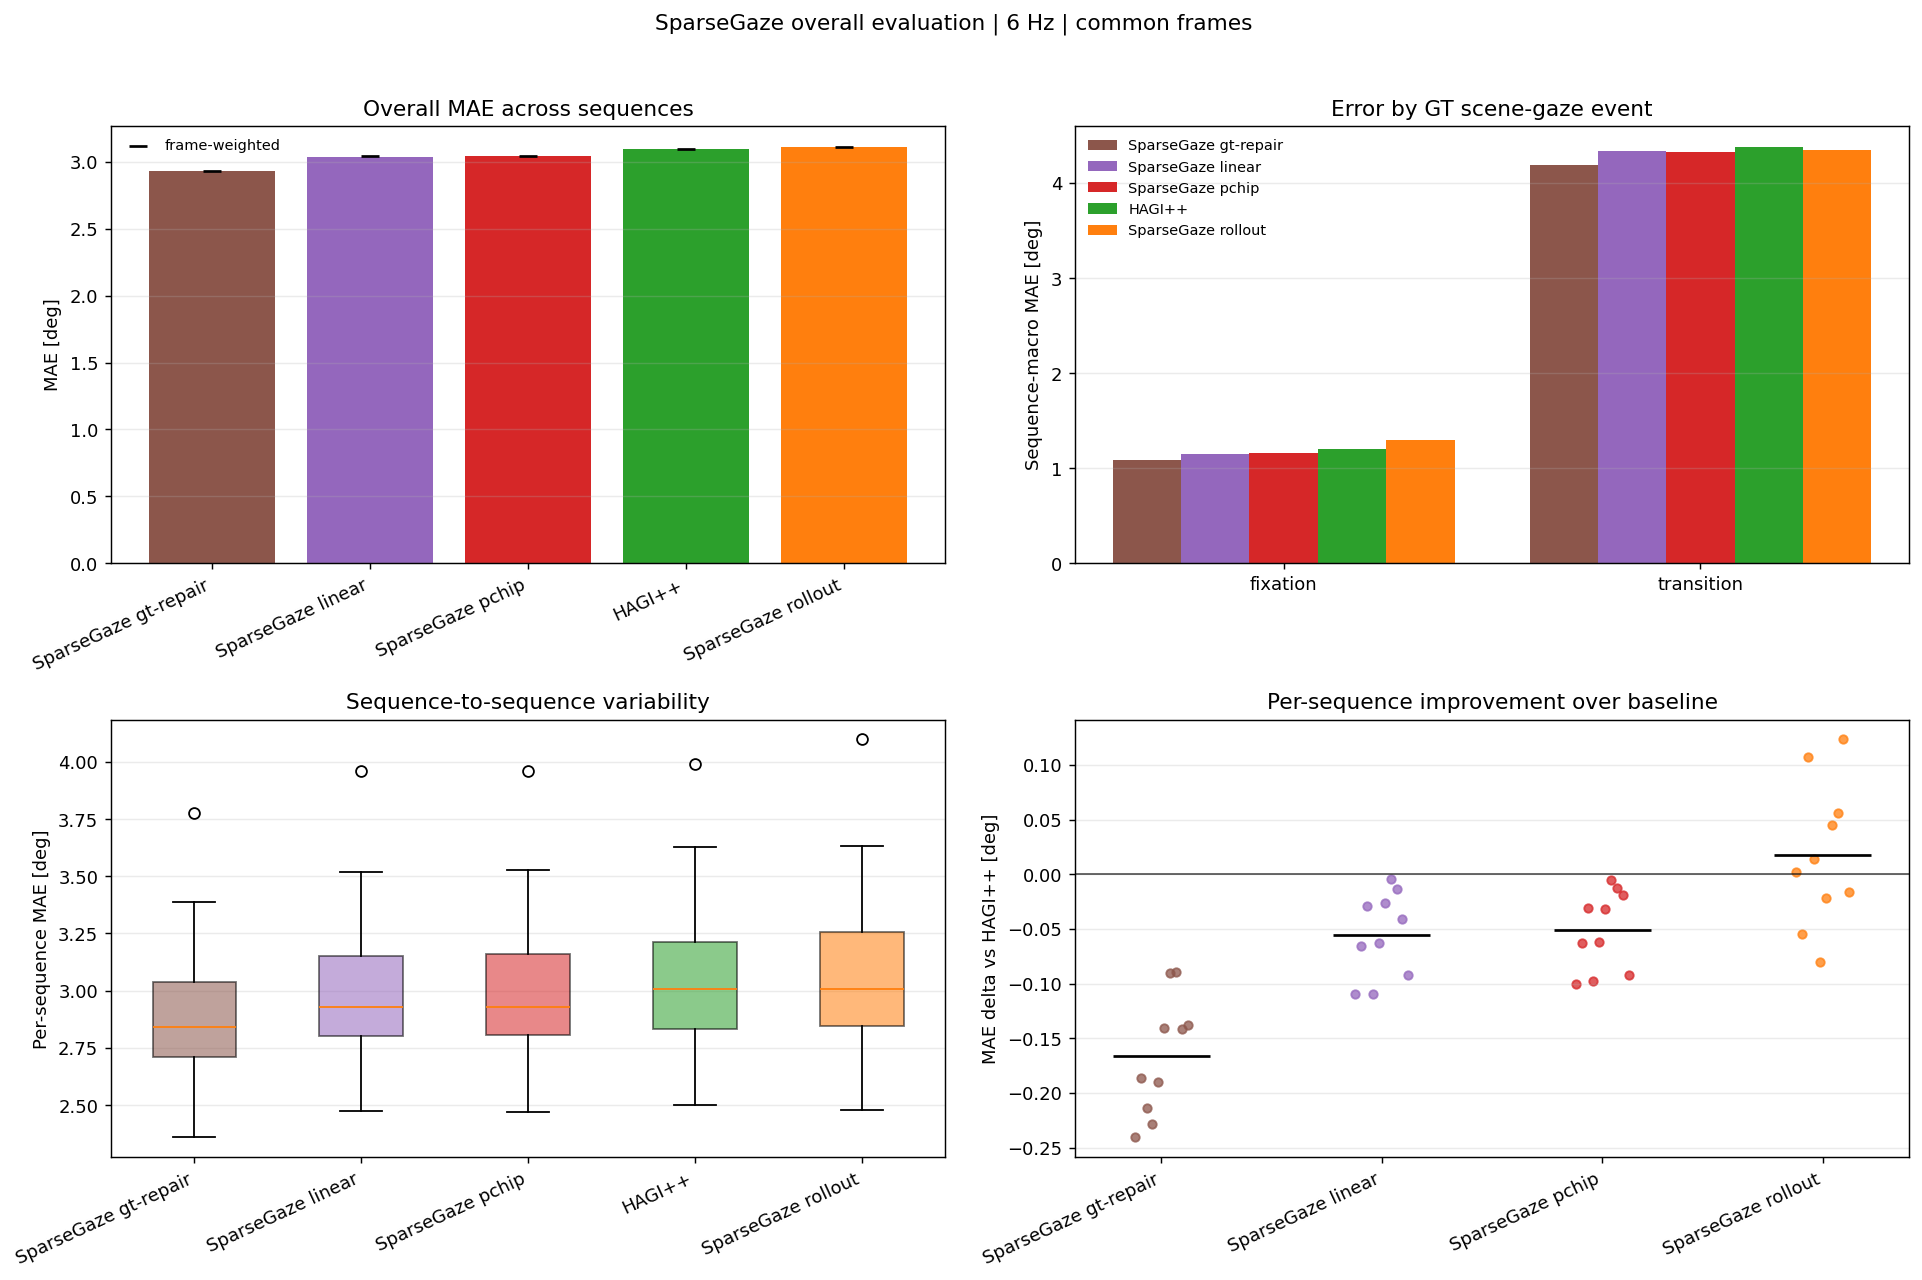

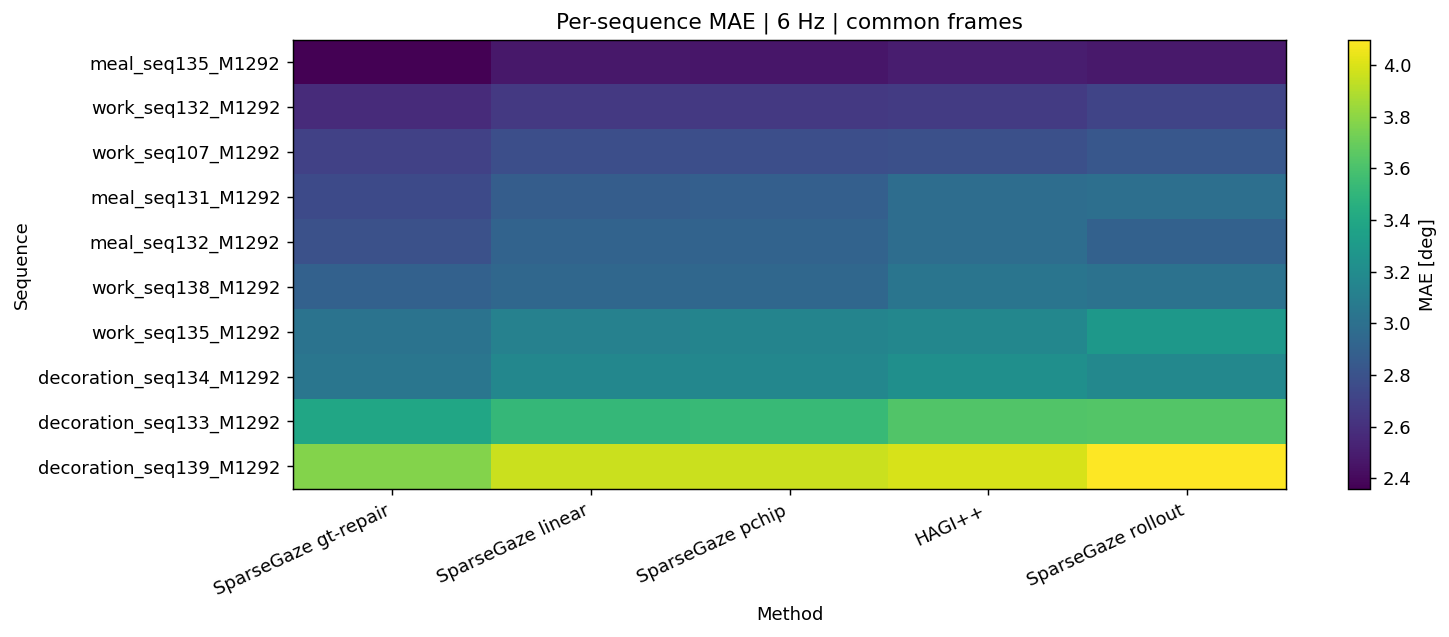

In [5]:
policy = "common frames" if USE_COMMON_FRAMES else "all available frames"
fig = overall.make_overall_dashboard(
    main_errors,
    title=f"SparseGaze overall evaluation | {FPS} Hz | {policy}",
)
display(fig)
plt.close(fig)

heatmap = overall.make_sequence_heatmap(
    sequence_summary,
    title=f"Per-sequence MAE | {FPS} Hz | {policy}",
)
display(heatmap)
plt.close(heatmap)

## Export Current Tables

In [6]:
OUTPUT_DIR = EXPERIMENT_DIR / "outputs" / "overall_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

main_errors.to_csv(OUTPUT_DIR / f"hz{FPS}_frame_errors.csv", index=False)
coverage.to_csv(OUTPUT_DIR / f"hz{FPS}_coverage.csv", index=False)
overall_summary.to_csv(OUTPUT_DIR / f"hz{FPS}_overall_summary.csv", index=False)
sequence_summary.to_csv(OUTPUT_DIR / f"hz{FPS}_sequence_summary.csv", index=False)
event_summary.to_csv(OUTPUT_DIR / f"hz{FPS}_event_summary.csv", index=False)
event_contrast.to_csv(OUTPUT_DIR / f"hz{FPS}_event_contrast.csv", index=False)
win_counts.to_csv(OUTPUT_DIR / f"hz{FPS}_win_counts.csv", index=False)

print("saved:", OUTPUT_DIR)

saved: /home/liumu/Github_Projects/adt_dataset_sandbox/Experiments/sparsegaze_evaluation/outputs/overall_notebook
